In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
grafo = nx.DiGraph()

grafo.add_weighted_edges_from([
    ("Centro", "Norte", 10),
    ("Centro", "Sur", 15),
    ("Centro", "Este", 25),
    ("Norte", "Este", 8),
    ("Norte", "Sur", 30),
    ("Norte", "Oeste", 15),
    ("Sur", "Oeste", 9),
    ("Este", "Aeropuerto", 20),
    ("Oeste", "Aeropuerto", 18)
])

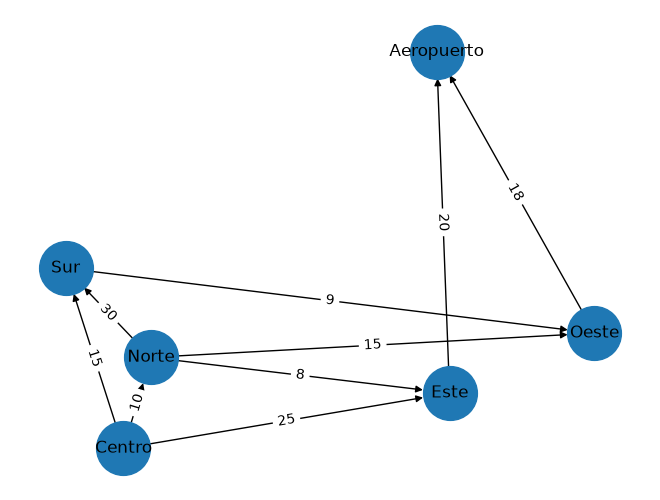

In [3]:
# Imprimimos el grafo

pos = nx.spring_layout(grafo, seed=12)

nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1500,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

plt.show()

In [4]:
# Mostramos las rutas

rutas = list(
    nx.all_simple_paths(
        grafo,
        source="Centro",
        target="Aeropuerto"
    )
)

In [5]:
# Imprimimos las rutas

for i, ruta in enumerate(rutas, start=1):
    print(f"Ruta {i}:{ruta}")

# Calculamos el costo
def costo_ruta(grafo, ruta):
    costo = 0
    for i in range(len(ruta)-1):
        costo += grafo[ruta[i]][ruta[i+1]]["weight"]
    return costo

Ruta 1:['Centro', 'Norte', 'Este', 'Aeropuerto']
Ruta 2:['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 3:['Centro', 'Norte', 'Oeste', 'Aeropuerto']
Ruta 4:['Centro', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 5:['Centro', 'Este', 'Aeropuerto']


In [6]:
# Imprimimos el costo
for i, ruta in enumerate(rutas, start=1):
    costo = costo_ruta(grafo, ruta)
    print(f"Ruta {i}:{ruta} -> {costo} unidades")

Ruta 1:['Centro', 'Norte', 'Este', 'Aeropuerto'] -> 38 unidades
Ruta 2:['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto'] -> 67 unidades
Ruta 3:['Centro', 'Norte', 'Oeste', 'Aeropuerto'] -> 43 unidades
Ruta 4:['Centro', 'Sur', 'Oeste', 'Aeropuerto'] -> 42 unidades
Ruta 5:['Centro', 'Este', 'Aeropuerto'] -> 45 unidades


In [8]:
# Elegir la ruta más corta
costos = [costo_ruta(grafo, ruta)
          for ruta in rutas
         ]

mejor_ruta = costos.index(min(costos))

In [9]:
# Imprimir la mejor ruta
print(f"La mejor ruta es: {mejor_ruta+1}")
print(f"El camino más corto es: {costos[mejor_ruta]}")

La mejor ruta es: 1
El camino más corto es: 38


In [23]:
ruta_mas_corta=nx.dijkstra_path(grafo, source="Centro",target="Aeropuerto",weight="weight")
tiempo_total=nx.dijkstra_path_length(grafo, source="Centro", target="Aeropuerto",weight="weight")

In [27]:
print(f"La ruta más corta es: {ruta_mas_corta}")
print(f"El tiempo total es: {tiempo_total}minutos")

La ruta más corta es: ['Centro', 'Norte', 'Este', 'Aeropuerto']
El tiempo total es: 38minutos
